# Task 4: Audio Classification Using CNN

## Objective

The objective of this task is to build a Convolutional Neural Network (CNN) for audio classification using an open-source dataset. The model is trained in two settings:

- Part A: Without SpecAugment
- Part B: With SpecAugment

The performance of both models is compared to analyze the effect of spectrogram augmentation on classification accuracy and model generalization.*italicized text*

In [2]:
#import req libs

import os
import random
import librosa
import librosa.display
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [5]:
dataset_path = "/content"

classes = [
    "yes",
    "no",
    "up",
    "down",
    "left",
    "right",
    "go",
    "stop"
]

## Dataset Study

The Google Speech Commands Dataset (Version 0.02) was selected for this task because it is a publicly available benchmark dataset for speech classification. To keep the training process computationally efficient, eight speech command classes were selected:

- yes
- no
- up
- down
- left
- right
- go
- stop

The dataset contains approximately 31,000 audio samples with a sampling rate of 16 kHz. Each audio clip has a duration of approximately one second. The class distribution is relatively balanced, making it suitable for training and evaluating a CNN-based audio classification model.

In [6]:
audio_files = []
labels = []

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        if file.endswith(".wav"):

            audio_files.append(
                os.path.join(folder, file)
            )

            labels.append(cls)

print("Total audio files:", len(audio_files))

Total audio files: 30956


In [7]:
summary = pd.DataFrame({
    "Class": labels
})

summary["Class"].value_counts()

,count
Class,
yes,4044
no,3941
down,3917
go,3880
stop,3872
left,3801
right,3778
up,3723


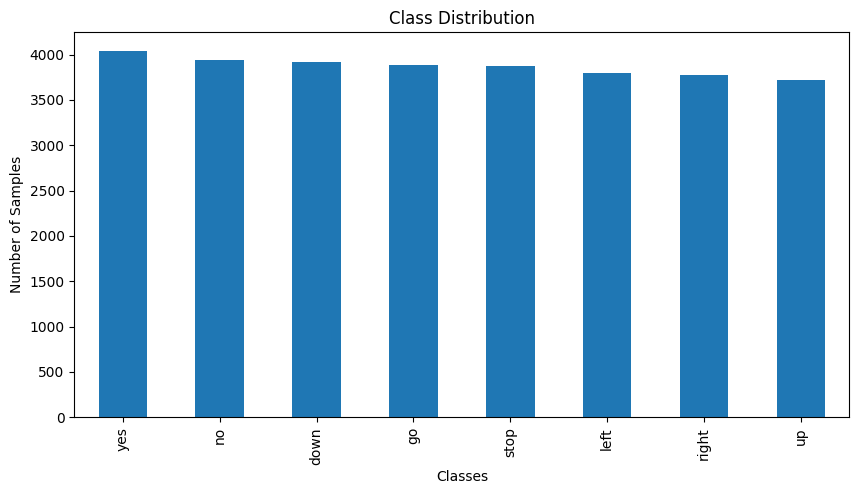

In [8]:
plt.figure(figsize=(10,5))

summary["Class"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")

plt.xlabel("Classes")

plt.ylabel("Number of Samples")

plt.show()

In [9]:
#step 1: dataset study

sample_audio, sample_rate = librosa.load(
    audio_files[0],
    sr=None
)

duration = len(sample_audio) / sample_rate

class_counts = summary["Class"].value_counts()

dataset_summary = pd.DataFrame({

    "Metric":[
        "Dataset Name",
        "Total Samples",
        "Number of Classes",
        "Sample Rate",
        "Audio Duration",
        "Most Frequent Class",
        "Least Frequent Class"
    ],

    "Value":[
        "Google Speech Commands v0.02",
        len(audio_files),
        len(classes),
        sample_rate,
        f"{duration:.2f} sec (example)",
        f"{class_counts.idxmax()} ({class_counts.max()})",
        f"{class_counts.idxmin()} ({class_counts.min()})"
    ]

})

dataset_summary

,Metric,Value
0,Dataset Name,Google Speech Commands v0.02
1,Total Samples,30956
2,Number of Classes,8
3,Sample Rate,16000
4,Audio Duration,1.00 sec (example)
5,Most Frequent Class,yes (4044)
6,Least Frequent Class,up (3723)


## Audio Sample Visualization

One representative audio sample from each class is selected for visualization. The waveform illustrates the signal amplitude over time, while the Mel spectrogram provides a time-frequency representation of the speech signal.

In [10]:
sample_files = {}

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    wav_file = sorted(os.listdir(folder))[0]

    sample_files[cls] = os.path.join(folder, wav_file)

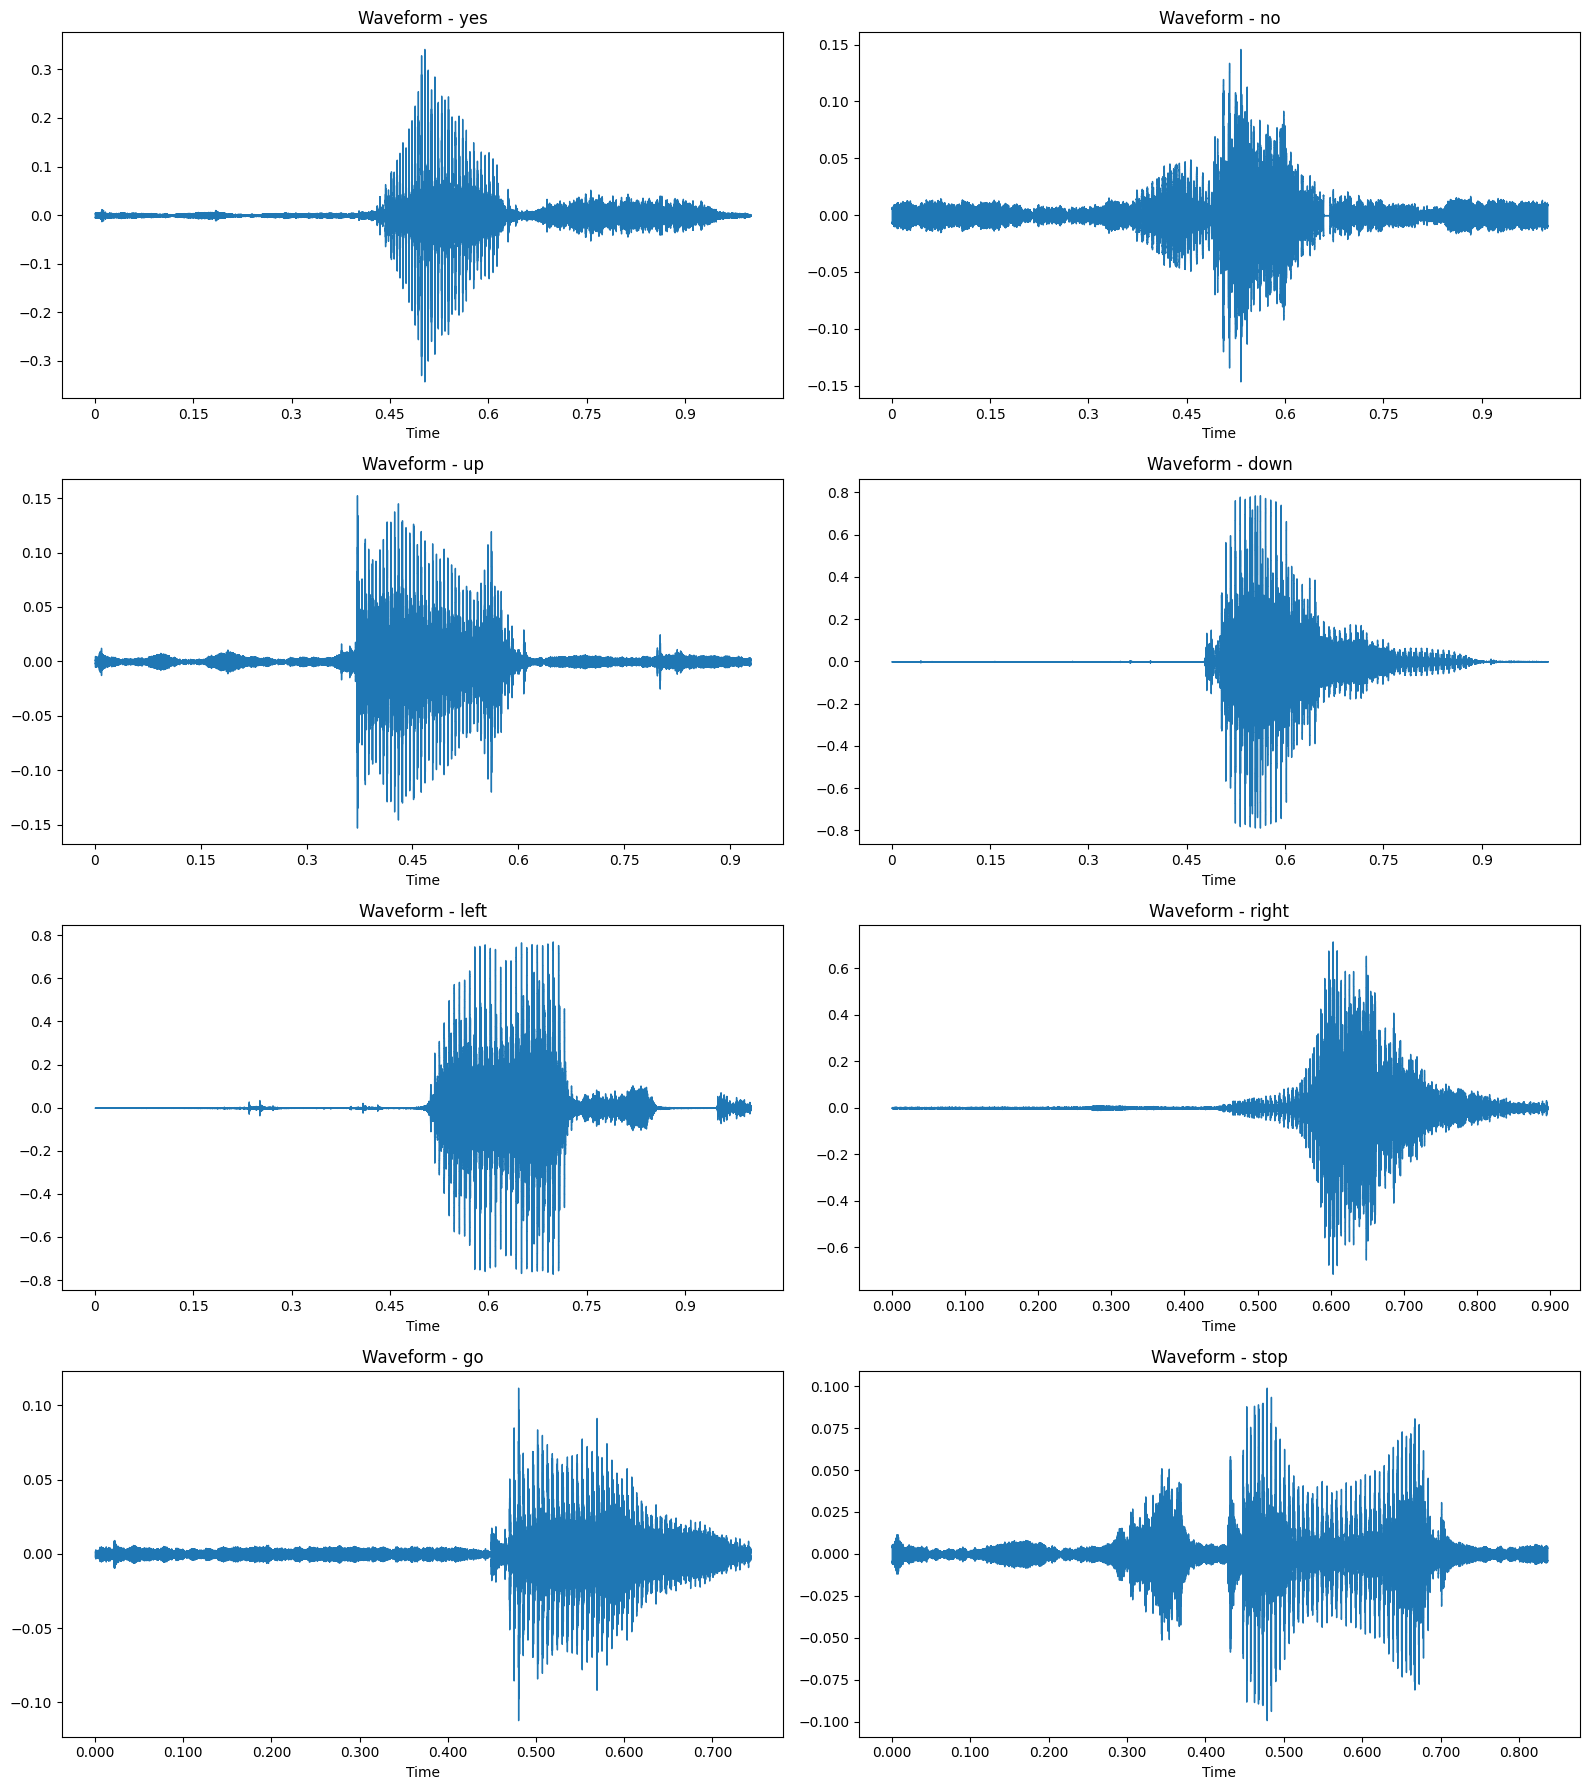

In [11]:
plt.figure(figsize=(16,18))

for i, cls in enumerate(classes):

    audio, sr = librosa.load(
        sample_files[cls],
        sr=16000
    )

    plt.subplot(4,2,i+1)

    librosa.display.waveshow(
        audio,
        sr=sr
    )

    plt.title(f"Waveform - {cls}")

plt.tight_layout()

plt.show()

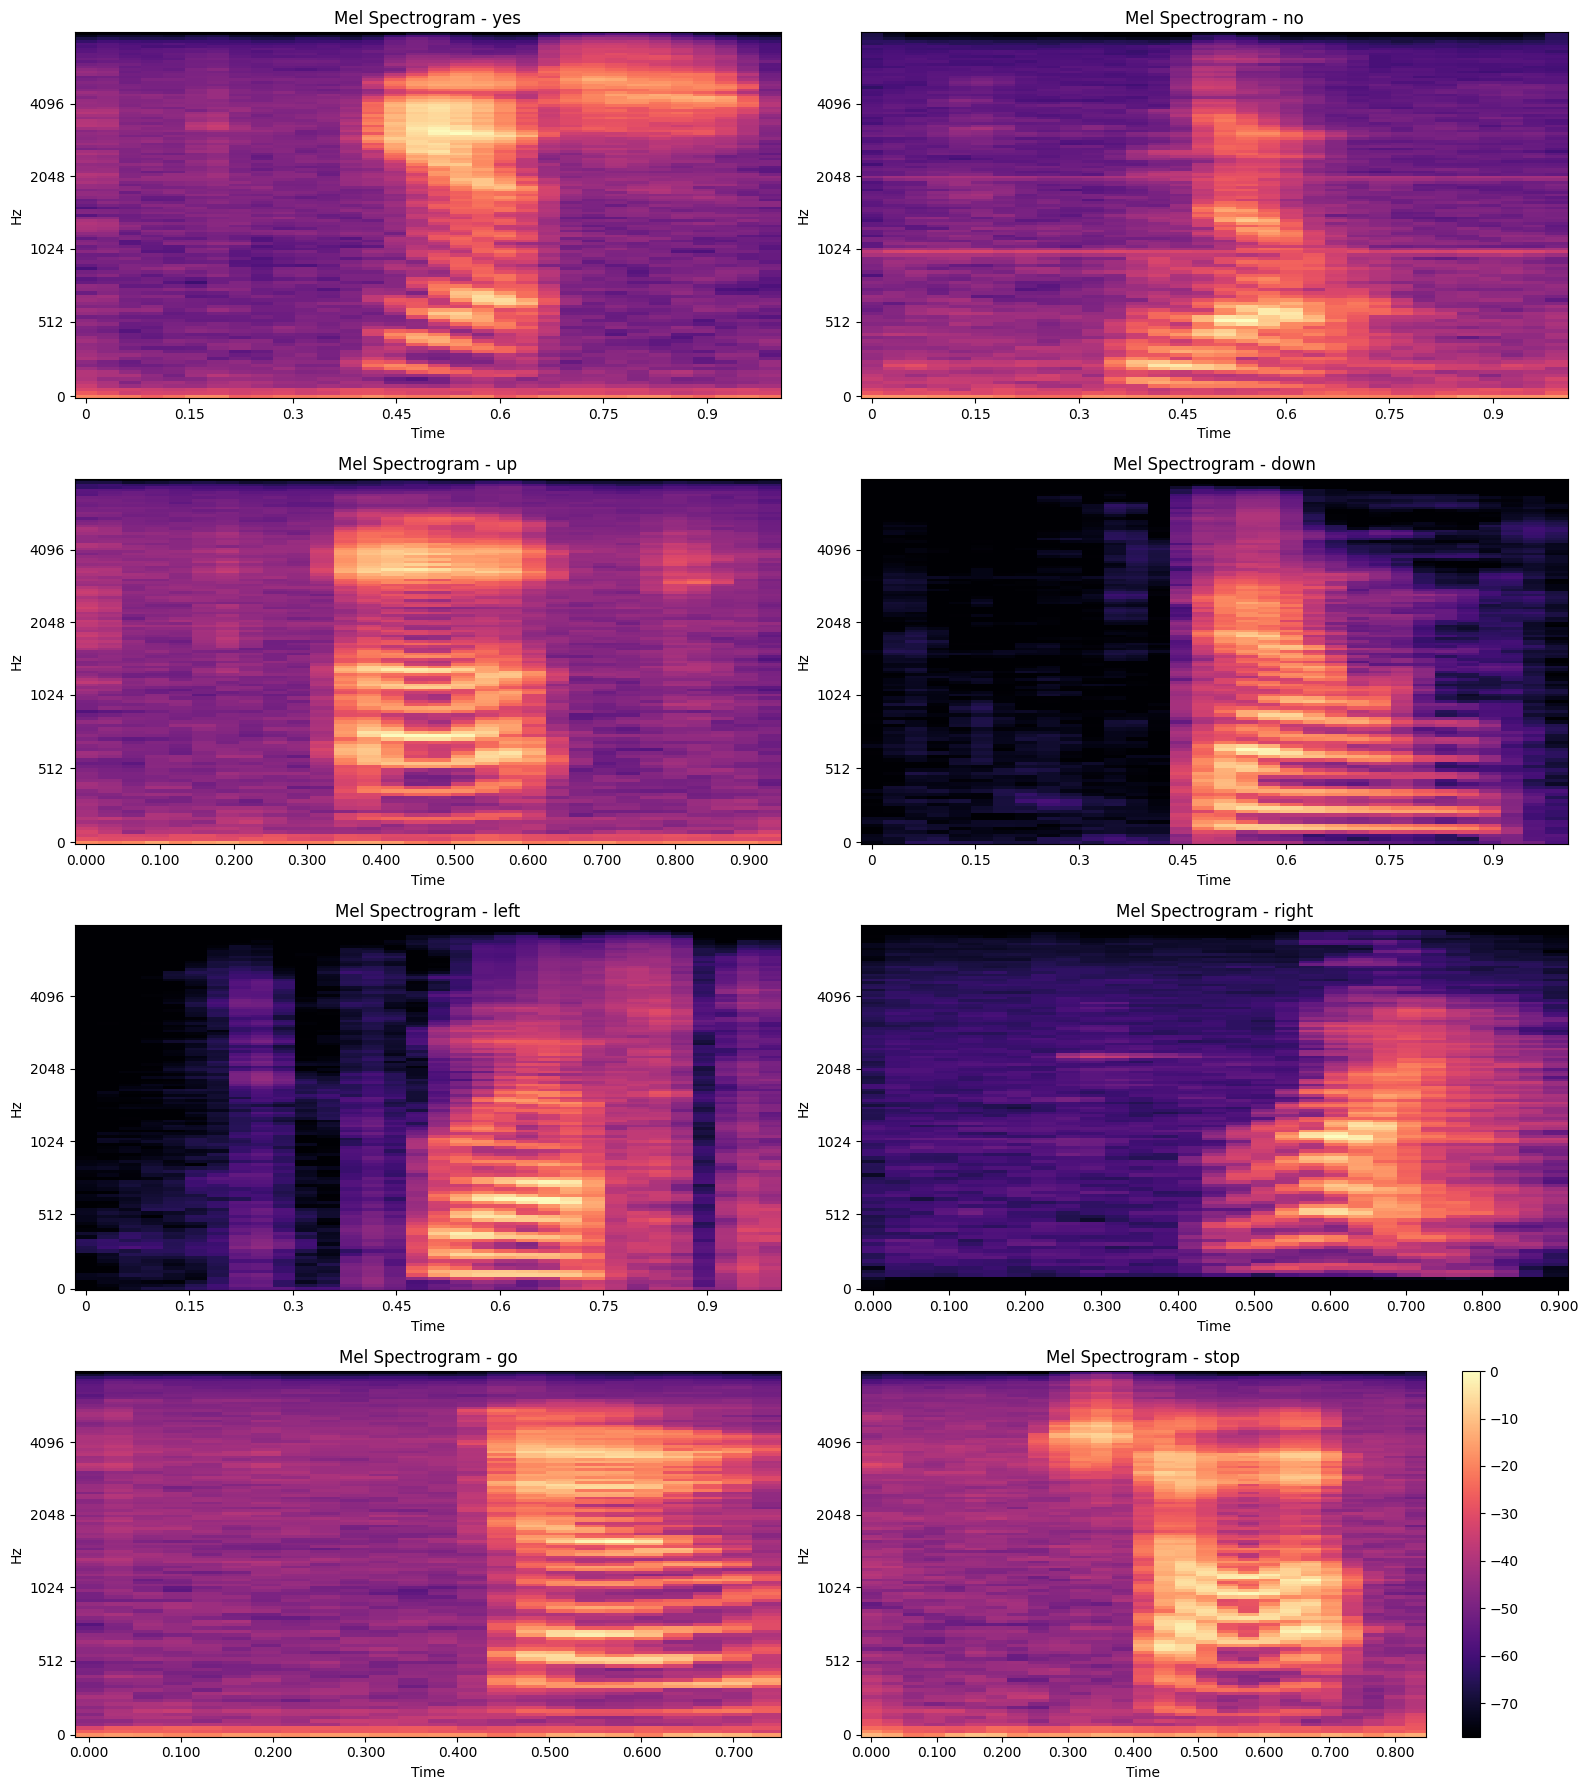

In [12]:
plt.figure(figsize=(16,18))

for i, cls in enumerate(classes):

    audio, sr = librosa.load(
        sample_files[cls],
        sr=16000
    )

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    plt.subplot(4,2,i+1)

    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel"
    )

    plt.title(f"Mel Spectrogram - {cls}")

plt.colorbar()

plt.tight_layout()

plt.show()


Waveform plots show the amplitude variations of each spoken command over time. Although all clips have approximately the same duration, each command exhibits a unique temporal pattern.

The Mel spectrograms highlight the distribution of speech energy across different frequency bands. Different spoken commands produce distinct spectral patterns, which can be learned effectively by a Convolutional Neural Network (CNN) for audio classification.

# Step 2: Audio Preprocessing

An audio preprocessing pipeline is implemented to prepare speech recordings for CNN training.

The preprocessing pipeline consists of:

1. Loading the audio file.
2. Converting to mono.
3. Resampling to 16 kHz.
4. Padding or truncating the signal to a fixed duration.
5. Extracting the Log Mel Spectrogram.

The final Log Mel Spectrogram is used as the CNN input.

In [13]:
class AudioPreprocessor:

    def __init__(
        self,
        sr=16000,
        n_mels=64,
        n_fft=1024,
        hop_length=512,
        target_duration=4.0
    ):

        self.sr = sr

        self.n_mels = n_mels

        self.n_fft = n_fft

        self.hop_length = hop_length

        self.target_samples = int(
            sr * target_duration
        )


    def load_and_resample(self, path):

        y, original_sr = librosa.load(
            path,
            sr=None,
            mono=True
        )

        if original_sr != self.sr:

            y = librosa.resample(
                y,
                orig_sr=original_sr,
                target_sr=self.sr
            )

        return y


    def pad_or_truncate(self, y):

        if len(y) < self.target_samples:

            padding = self.target_samples - len(y)

            y = np.pad(
                y,
                (0, padding)
            )

        else:

            y = y[:self.target_samples]

        return y


    def extract_mel_spectrogram(self, y):

        mel = librosa.feature.melspectrogram(

            y=y,

            sr=self.sr,

            n_fft=self.n_fft,

            hop_length=self.hop_length,

            n_mels=self.n_mels

        )

        log_mel = librosa.power_to_db(
            mel,
            ref=np.max
        )

        log_mel = np.expand_dims(
            log_mel,
            axis=0
        )

        return log_mel


    def process(self, path):

        y = self.load_and_resample(path)

        y = self.pad_or_truncate(y)

        mel = self.extract_mel_spectrogram(y)

        return mel

In [14]:
preprocessor = AudioPreprocessor()

sample_path = audio_files[0]

mel = preprocessor.process(
    sample_path
)

print("Mel Spectrogram Shape:", mel.shape)

Mel Spectrogram Shape: (1, 64, 126)


In [15]:
example_path = audio_files[0]

# Raw audio
raw_audio, raw_sr = librosa.load(
    example_path,
    sr=None
)

# Resampled audio
resampled_audio = preprocessor.load_and_resample(
    example_path
)

# Fixed-length audio
fixed_audio = preprocessor.pad_or_truncate(
    resampled_audio
)

# Log Mel Spectrogram
log_mel = preprocessor.extract_mel_spectrogram(
    fixed_audio
)

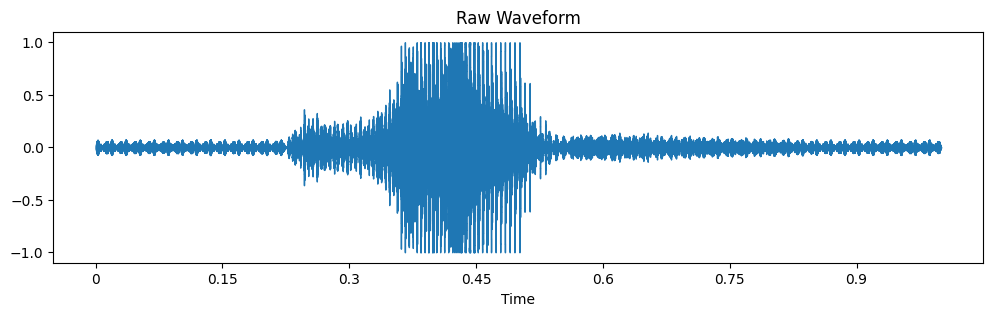

In [16]:
plt.figure(figsize=(12,3))

librosa.display.waveshow(
    raw_audio,
    sr=raw_sr
)

plt.title("Raw Waveform")

plt.show()

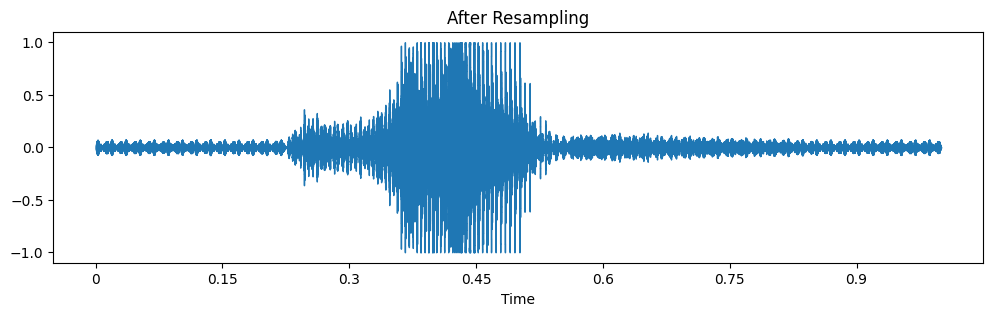

In [17]:
plt.figure(figsize=(12,3))

librosa.display.waveshow(
    resampled_audio,
    sr=16000
)

plt.title("After Resampling")

plt.show()

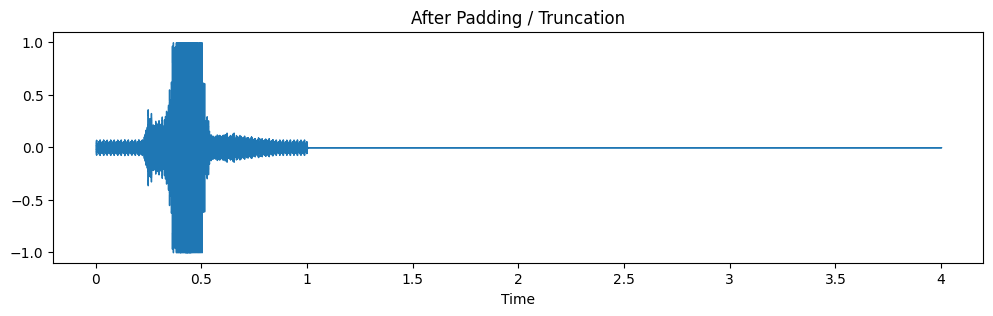

In [18]:
plt.figure(figsize=(12,3))

librosa.display.waveshow(
    fixed_audio,
    sr=16000
)

plt.title("After Padding / Truncation")

plt.show()

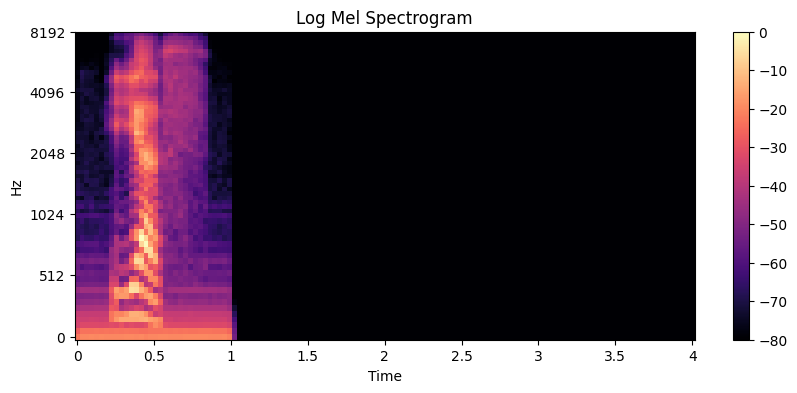

In [19]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    log_mel[0],
    sr=16000,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Log Mel Spectrogram")

plt.show()

# Step 3: Dataset and DataLoader

The custom PyTorch Dataset class is used to load audio files, preprocess them into Log Mel Spectrograms, and return spectrogram-label pairs. The dataset is then divided into training, validation, and testing subsets for CNN training and evaluation.

In [20]:
label_to_index = {

    label: idx

    for idx, label in enumerate(classes)

}

index_to_label = {

    idx: label

    for label, idx in label_to_index.items()

}

numeric_labels = [

    label_to_index[label]

    for label in labels

]

print(label_to_index)

{'yes': 0, 'no': 1, 'up': 2, 'down': 3, 'left': 4, 'right': 5, 'go': 6, 'stop': 7}


In [82]:
class AudioDataset(Dataset):

    def __init__(

        self,

        file_list,

        labels,

        preprocessor,

        augment=None

    ):

        self.file_list = file_list

        self.labels = labels

        self.preprocessor = preprocessor

        self.augment = augment


    def __len__(self):

        return len(self.file_list)


    def __getitem__(self, idx):

        path = self.file_list[idx]

        label = self.labels[idx]

        spectrogram = self.preprocessor.process(path)

        spectrogram = torch.tensor(

            spectrogram,

            dtype=torch.float32

        )

        if self.augment is not None:

          if random.random() < 0.5:

              spectrogram = self.augment(spectrogram)

        return spectrogram, label

In [22]:
train_files, temp_files, train_labels, temp_labels = train_test_split(

    audio_files,

    numeric_labels,

    test_size=0.30,

    random_state=42,

    stratify=numeric_labels

)

val_files, test_files, val_labels, test_labels = train_test_split(

    temp_files,

    temp_labels,

    test_size=0.50,

    random_state=42,

    stratify=temp_labels

)

print("Train :", len(train_files))

print("Validation :", len(val_files))

print("Test :", len(test_files))

Train : 21669
Validation : 4643
Test : 4644


In [23]:
train_dataset = AudioDataset(

    train_files,

    train_labels,

    preprocessor

)

val_dataset = AudioDataset(

    val_files,

    val_labels,

    preprocessor

)

test_dataset = AudioDataset(

    test_files,

    test_labels,

    preprocessor

)

In [24]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False

)

In [25]:
images, labels = next(

    iter(train_loader)

)

print("Input Shape :", images.shape)

print("Labels Shape :", labels.shape)

Input Shape : torch.Size([32, 1, 64, 126])
Labels Shape : torch.Size([32])


# Step 4: CNN Model Architecture

A Convolutional Neural Network (CNN) is designed to classify speech commands using Log Mel Spectrograms as input.

The model consists of:

- Three Convolutional Blocks
- Batch Normalization
- ReLU Activation
- Max Pooling
- Dropout Layer
- Fully Connected Output Layer

Batch Normalization improves training stability, while Dropout helps reduce overfitting.

In [78]:
class AudioCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*8*15,128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,num_classes)

        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

In [27]:
model = AudioCNN(
    num_classes=len(classes)
)

print(model)

AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=7680, out_features=128, bi

In [28]:
dummy = torch.randn(
    1,
    1,
    64,
    126
)

output = model(dummy)

print(output.shape)

torch.Size([1, 8])


# Step 5: Training Without Augmentation

The CNN model is trained without using any spectrogram augmentation. CrossEntropyLoss is used as the loss function, while the Adam optimizer updates the model parameters.

Training and validation accuracy are recorded after every epoch to monitor learning performance and possible overfitting.

In [29]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print(device)

model = model.to(device)

cuda


In [30]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

In [32]:
epochs = 5

train_losses = []

train_accuracies = []

val_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    correct = 0

    total = 0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(

            outputs,

            labels

        )

        loss.backward()

        optimizer.step()


        running_loss += loss.item()

        _, predicted = torch.max(

            outputs,

            1

        )

        total += labels.size(0)

        correct += (

            predicted == labels

        ).sum().item()


    train_loss = running_loss / len(train_loader)

    train_accuracy = correct / total


    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)


    model.eval()

    correct = 0

    total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(

                outputs,

                1

            )

            total += labels.size(0)

            correct += (

                predicted == labels

            ).sum().item()


    val_accuracy = correct / total

    val_accuracies.append(

        val_accuracy

    )


    print(

        f"Epoch {epoch+1}/{epochs} | "

        f"Loss: {train_loss:.4f} | "

        f"Train Acc: {train_accuracy:.4f} | "

        f"Val Acc: {val_accuracy:.4f}"

    )

Epoch 1/5 | Loss: 0.5057 | Train Acc: 0.8115 | Val Acc: 0.8727
Epoch 2/5 | Loss: 0.4335 | Train Acc: 0.8366 | Val Acc: 0.8546
Epoch 3/5 | Loss: 0.3988 | Train Acc: 0.8514 | Val Acc: 0.9268
Epoch 4/5 | Loss: 0.3559 | Train Acc: 0.8690 | Val Acc: 0.8908
Epoch 5/5 | Loss: 0.3308 | Train Acc: 0.8734 | Val Acc: 0.9014


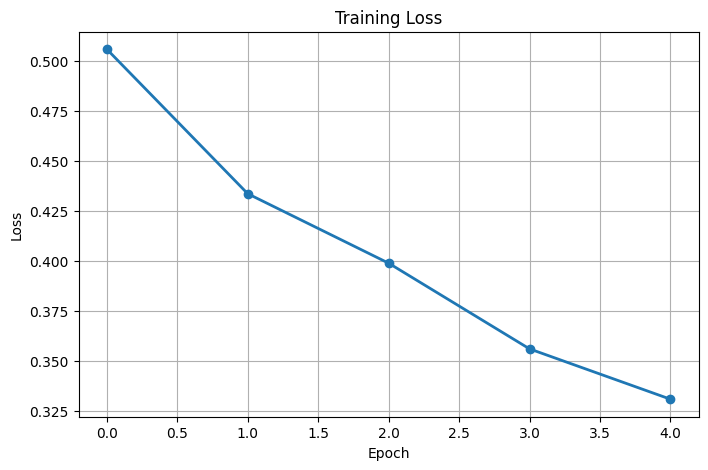

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    marker="o",
    linewidth=2
)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

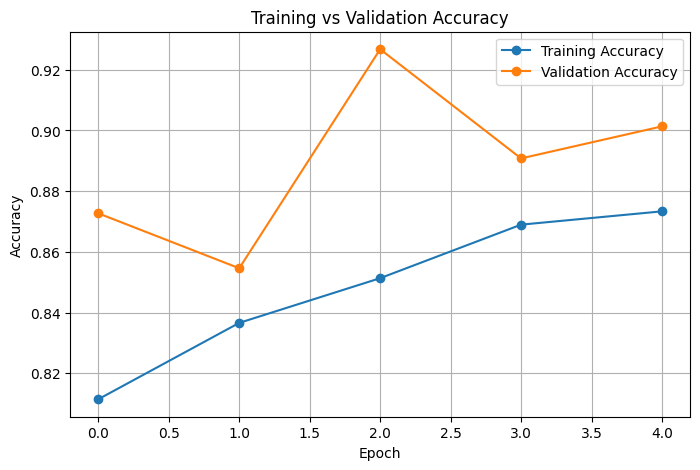

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

## Observation

The CNN model was trained for five epochs without applying SpecAugment. The training loss decreased steadily across epochs, indicating successful optimization of the network parameters.

Training accuracy improved from approximately 81% to 87%, while validation accuracy reached around 90%. The validation accuracy remained close to the training accuracy, suggesting that the model generalized well without severe overfitting. These results establish the baseline performance for comparison with the SpecAugment-based model in Part B.

# Step 6: Evaluation Without Augmentation

The trained CNN model is evaluated using the held-out test dataset. Performance is measured using accuracy, precision, recall, F1-score, and a confusion matrix. Correct and incorrect predictions are also visualized to understand the model's strengths and weaknesses.

In [35]:
model.eval()

all_predictions = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

In [36]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8981
Precision : 0.9088
Recall    : 0.8982
F1 Score  : 0.8954


In [37]:
print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=classes

    )

)

              precision    recall  f1-score   support

         yes       0.96      0.96      0.96       607
          no       0.78      0.92      0.84       591
          up       0.95      0.91      0.93       558
        down       0.90      0.92      0.91       588
        left       0.79      0.99      0.88       570
       right       0.97      0.93      0.95       567
          go       0.98      0.59      0.74       582
        stop       0.94      0.96      0.95       581

    accuracy                           0.90      4644
   macro avg       0.91      0.90      0.90      4644
weighted avg       0.91      0.90      0.90      4644



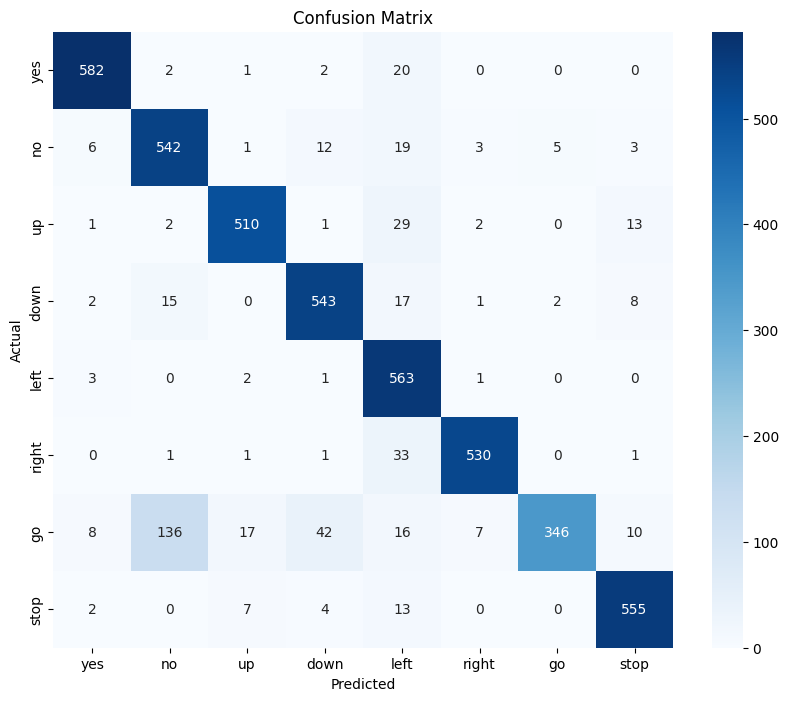

In [38]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=classes,

    yticklabels=classes

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Observation

The CNN model achieved a test accuracy of approximately **89.81%** without applying SpecAugment. The macro precision, recall, and F1-score were all close to 90%, indicating balanced classification performance across the selected speech command classes.

The confusion matrix shows that most speech commands were classified correctly, particularly **yes**, **up**, **down**, **left**, **right**, and **stop**. The **go** class produced the largest number of misclassifications, suggesting that its acoustic characteristics overlap with several other short speech commands. Overall, the model demonstrated good generalization performance and provides a strong baseline for comparison with the SpecAugment model.

| Metric                |      Value |
| --------------------- | ---------: |
| **Test Accuracy**     | **89.81%** |
| **Precision (Macro)** | **90.88%** |
| **Recall (Macro)**    | **89.82%** |
| **F1-Score (Macro)**  | **89.54%** |


In [39]:
prediction_details = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):

            prediction_details.append({

                "image": images[i].cpu(),

                "actual": labels[i].item(),

                "predicted": predicted[i].cpu().item()

            })

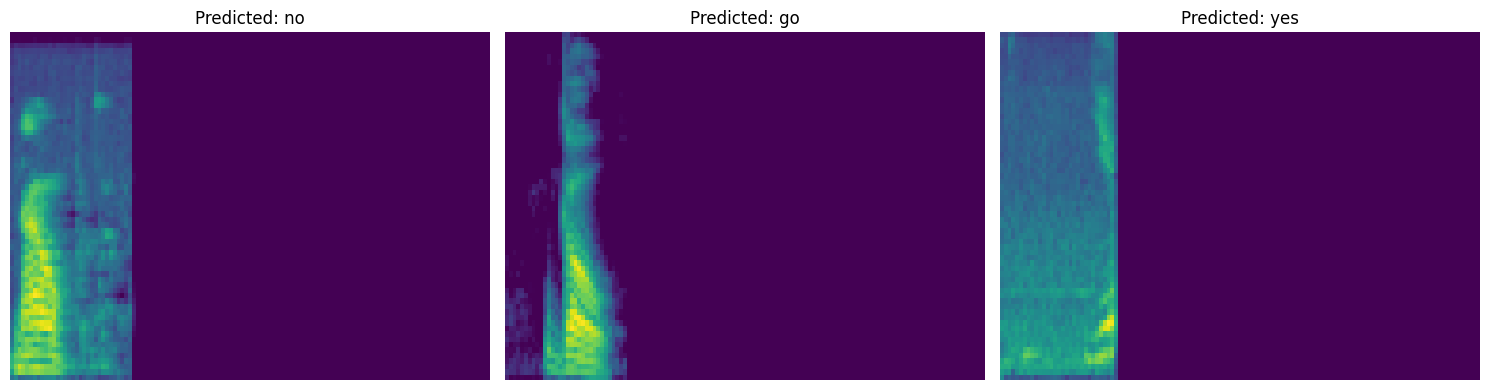

In [40]:
correct = [

    p for p in prediction_details

    if p["actual"] == p["predicted"]

][:3]

plt.figure(figsize=(15,4))

for i, sample in enumerate(correct):

    plt.subplot(1,3,i+1)

    plt.imshow(

        sample["image"][0],

        aspect="auto",

        origin="lower"

    )

    plt.title(

        f"Predicted: {classes[sample['predicted']]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()

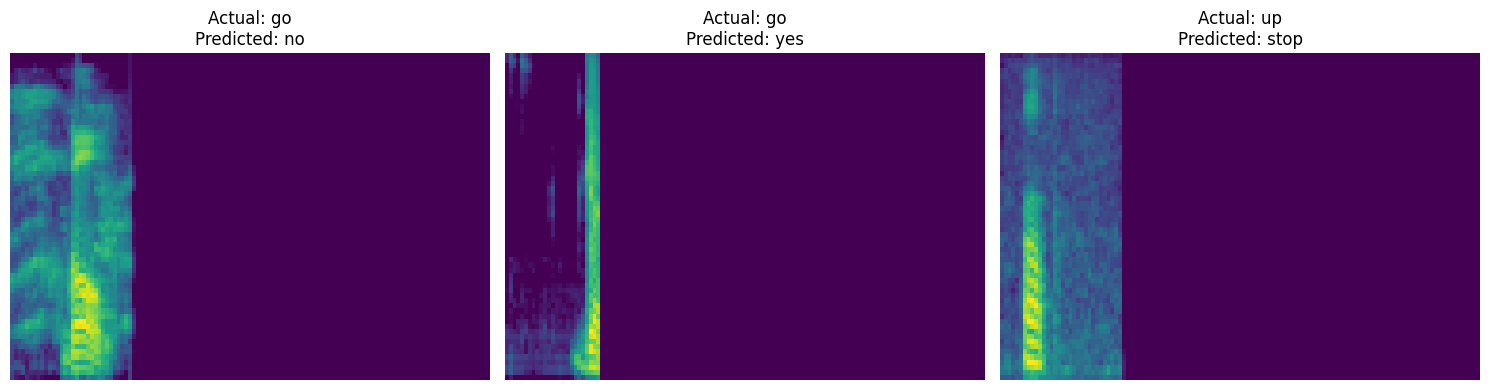

In [41]:
incorrect = [

    p for p in prediction_details

    if p["actual"] != p["predicted"]

][:3]

plt.figure(figsize=(15,4))

for i, sample in enumerate(incorrect):

    plt.subplot(1,3,i+1)

    plt.imshow(

        sample["image"][0],

        aspect="auto",

        origin="lower"

    )

    plt.title(

        f"Actual: {classes[sample['actual']]}\n"

        f"Predicted: {classes[sample['predicted']]}"

    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# Step 7: Implement SpecAugment

SpecAugment is a spectrogram augmentation technique that improves model generalization by randomly masking frequency bands and time frames during training.

Unlike image augmentation, SpecAugment operates directly on the Log Mel Spectrogram. Frequency masking simulates missing frequency information, while time masking simulates missing temporal information. These augmentations help reduce overfitting and improve robustness.

In [58]:
import random

class SpecAugment:

    def __init__(
        self,
        freq_mask_param=8,
        time_mask_param=15,
        num_freq_masks=1,
        num_time_masks=1
    ):

        self.F = freq_mask_param
        self.T = time_mask_param

        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks


    def freq_mask(self, spec):

        _, n_mels, _ = spec.shape

        f = random.randint(0, self.F)

        f0 = random.randint(0, max(0, n_mels - f))

        spec[:, f0:f0+f, :] = 0

        return spec


    def time_mask(self, spec):

        _, _, n_frames = spec.shape

        t = random.randint(0, self.T)

        t0 = random.randint(0, max(0, n_frames - t))

        spec[:, :, t0:t0+t] = 0

        return spec


    def __call__(self, spec):

        spec = spec.clone()

        for _ in range(self.num_freq_masks):

            spec = self.freq_mask(spec)

        for _ in range(self.num_time_masks):

            spec = self.time_mask(spec)

        return spec

In [59]:
augment = SpecAugment()

In [60]:
sample_spec = train_dataset[0][0]

augmented = augment(sample_spec)

print(sample_spec.shape)

print(augmented.shape)

torch.Size([1, 64, 126])
torch.Size([1, 64, 126])


# Step 8: Visualize SpecAugment

The effect of SpecAugment is visualized by applying frequency masking, time masking, and the complete augmentation pipeline to a single Log Mel Spectrogram.

Two additional random augmentations are also shown to demonstrate the stochastic nature of SpecAugment.

In [61]:
sample_spec = train_dataset[0][0].clone()

In [62]:
freq_only = sample_spec.clone()

freq_only = augment.freq_mask(freq_only)

In [63]:
time_only = sample_spec.clone()

time_only = augment.time_mask(time_only)

In [64]:
full_aug = augment(
    sample_spec.clone()
)

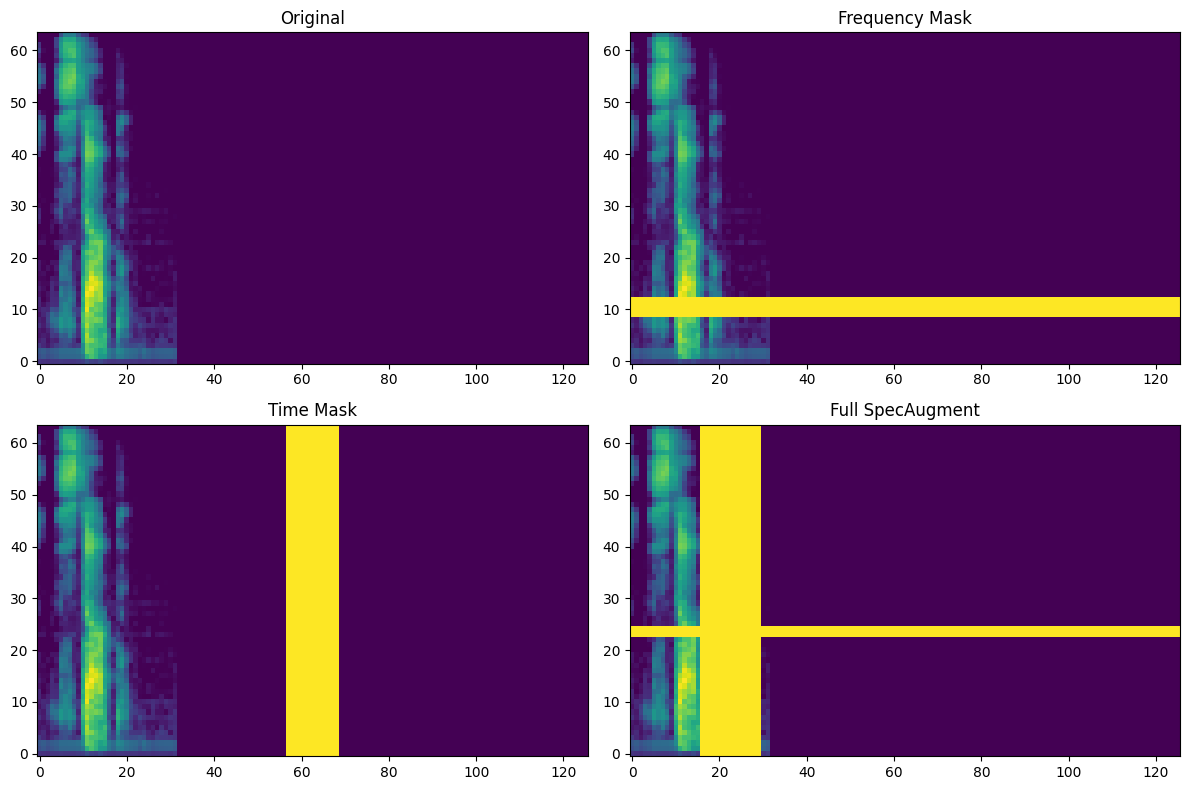

In [65]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

plots = [

    (sample_spec, "Original"),

    (freq_only, "Frequency Mask"),

    (time_only, "Time Mask"),

    (full_aug, "Full SpecAugment")

]

for ax, (spec, title) in zip(

    axes.ravel(),

    plots

):

    ax.imshow(

        spec[0],

        aspect="auto",

        origin="lower"

    )

    ax.set_title(title)

plt.tight_layout()

plt.show()

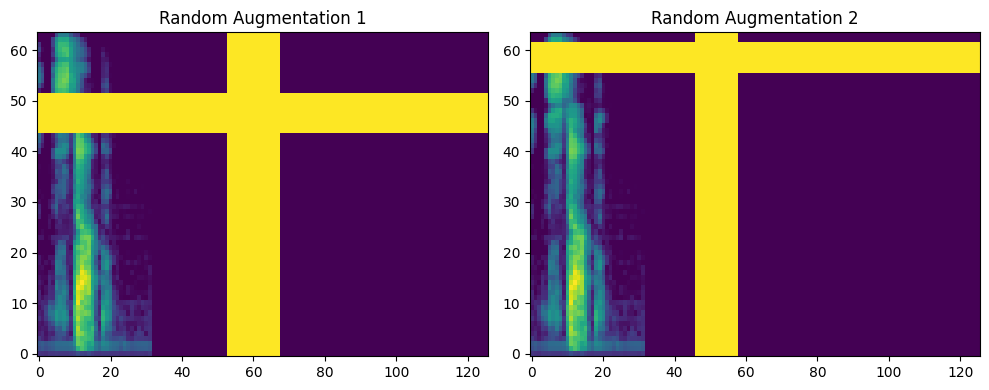

In [66]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10,4)
)

for i in range(2):

    aug_spec = augment(

        sample_spec.clone()

    )

    axes[i].imshow(

        aug_spec[0],

        aspect="auto",

        origin="lower"

    )

    axes[i].set_title(

        f"Random Augmentation {i+1}"

    )

plt.tight_layout()

plt.show()

# Step 9: Training With SpecAugment

The same CNN architecture, hyperparameters, optimizer, and data split are used as in Part A.

The only difference is that SpecAugment is applied to the training spectrograms before they are fed into the CNN. Validation and test datasets remain unchanged.

In [67]:
train_dataset_aug = AudioDataset(

    train_files,

    train_labels,

    preprocessor,

    augment=augment

)

In [68]:
train_loader_aug = DataLoader(

    train_dataset_aug,

    batch_size=32,

    shuffle=True

)

In [83]:
model_aug = AudioCNN(
    num_classes=len(classes)
).to(device)

In [84]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    model_aug.parameters(),

    lr=0.001

)

In [85]:
epochs = 5

train_losses_aug = []

train_accuracies_aug = []

val_accuracies_aug = []

for epoch in range(epochs):

    model_aug.train()

    running_loss = 0

    correct = 0

    total = 0


    for images, labels in train_loader_aug:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_aug(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()


    train_loss = running_loss / len(train_loader_aug)

    train_accuracy = correct / total

    train_losses_aug.append(train_loss)

    train_accuracies_aug.append(train_accuracy)


    model_aug.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model_aug(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()


    val_accuracy = correct / total

    val_accuracies_aug.append(val_accuracy)


    print(

        f"Epoch {epoch+1}/{epochs} | "

        f"Loss: {train_loss:.4f} | "

        f"Train Acc: {train_accuracy:.4f} | "

        f"Val Acc: {val_accuracy:.4f}"

    )

Epoch 1/5 | Loss: 2.0556 | Train Acc: 0.1684 | Val Acc: 0.2837
Epoch 2/5 | Loss: 1.5204 | Train Acc: 0.4198 | Val Acc: 0.6013
Epoch 3/5 | Loss: 1.1257 | Train Acc: 0.5846 | Val Acc: 0.7252
Epoch 4/5 | Loss: 0.8503 | Train Acc: 0.6880 | Val Acc: 0.7984
Epoch 5/5 | Loss: 0.7516 | Train Acc: 0.7259 | Val Acc: 0.8096


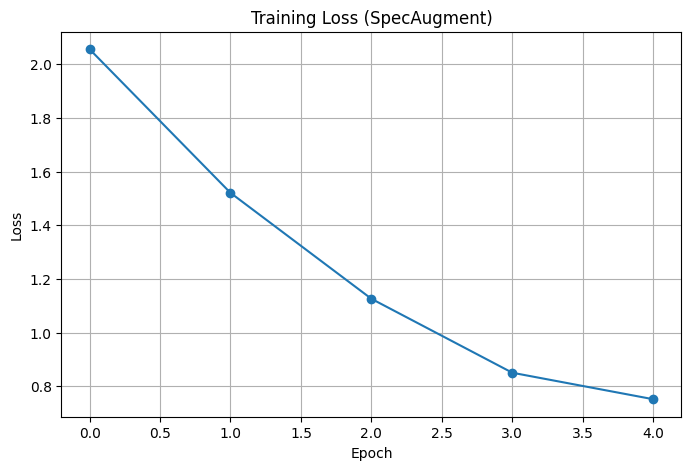

In [86]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses_aug,
    marker="o"
)

plt.title("Training Loss (SpecAugment)")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

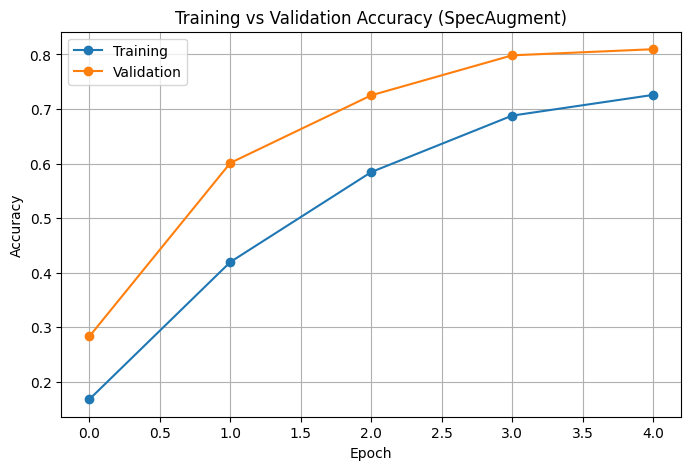

In [87]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accuracies_aug,
    marker="o",
    label="Training"
)

plt.plot(
    val_accuracies_aug,
    marker="o",
    label="Validation"
)

plt.title("Training vs Validation Accuracy (SpecAugment)")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [88]:
model_aug.eval()

all_predictions_aug = []

all_labels_aug = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model_aug(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions_aug.extend(
            predicted.cpu().numpy()
        )

        all_labels_aug.extend(
            labels.cpu().numpy()
        )

In [89]:
accuracy_aug = accuracy_score(
    all_labels_aug,
    all_predictions_aug
)

precision_aug = precision_score(
    all_labels_aug,
    all_predictions_aug,
    average="macro"
)

recall_aug = recall_score(
    all_labels_aug,
    all_predictions_aug,
    average="macro"
)

f1_aug = f1_score(
    all_labels_aug,
    all_predictions_aug,
    average="macro"
)

print(f"Accuracy  : {accuracy_aug:.4f}")

print(f"Precision : {precision_aug:.4f}")

print(f"Recall    : {recall_aug:.4f}")

print(f"F1 Score  : {f1_aug:.4f}")

Accuracy  : 0.8161
Precision : 0.8179
Recall    : 0.8161
F1 Score  : 0.8133


In [90]:
print(

    classification_report(

        all_labels_aug,

        all_predictions_aug,

        target_names=classes

    )

)

              precision    recall  f1-score   support

         yes       0.89      0.95      0.92       607
          no       0.67      0.75      0.71       591
          up       0.86      0.87      0.87       558
        down       0.74      0.81      0.77       588
        left       0.81      0.82      0.81       570
       right       0.91      0.88      0.90       567
          go       0.78      0.53      0.63       582
        stop       0.89      0.91      0.90       581

    accuracy                           0.82      4644
   macro avg       0.82      0.82      0.81      4644
weighted avg       0.82      0.82      0.81      4644



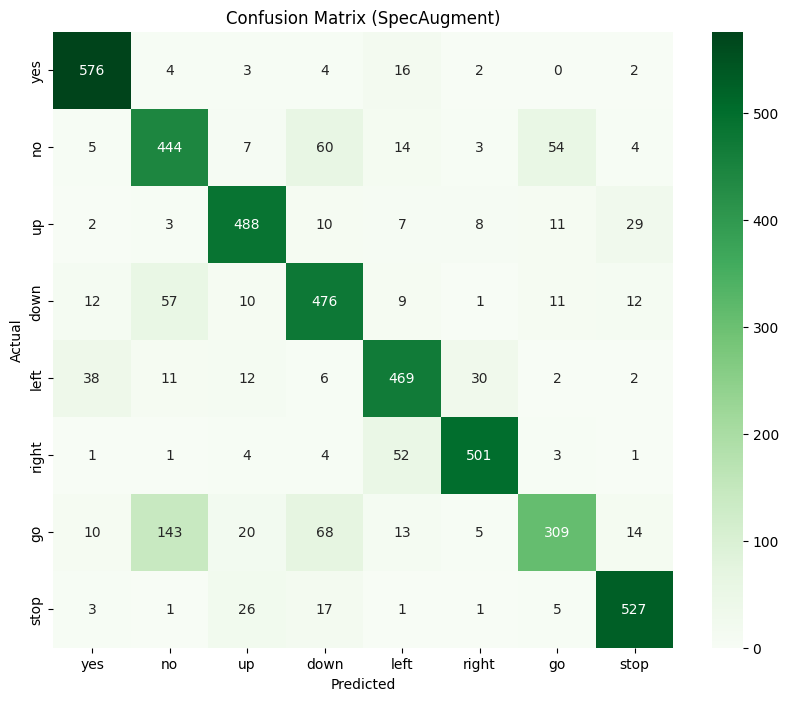

In [91]:
cm_aug = confusion_matrix(

    all_labels_aug,

    all_predictions_aug

)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm_aug,

    annot=True,

    fmt="d",

    cmap="Greens",

    xticklabels=classes,

    yticklabels=classes

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix (SpecAugment)")

plt.show()

In [92]:
comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Without SpecAugment":[

        accuracy,

        precision,

        recall,

        f1

    ],

    "With SpecAugment":[

        accuracy_aug,

        precision_aug,

        recall_aug,

        f1_aug

    ]

})

comparison

,Metric,Without SpecAugment,With SpecAugment
0,Accuracy,0.898148,0.816107
1,Precision,0.908798,0.817942
2,Recall,0.898196,0.816083
3,F1 Score,0.895413,0.813329


# Final Comparison and Conclusion

Two CNN-based speech command classifiers were trained and evaluated using the same dataset and preprocessing pipeline. The first model was trained without augmentation, while the second model used SpecAugment with random frequency and time masking during training.

The baseline model achieved higher performance, with a test accuracy of **89.81%**, compared to **81.61%** for the SpecAugment model. Similar trends were observed for precision, recall, and F1-score.

The lower performance of the SpecAugment model is expected because the augmentation intentionally masks portions of the spectrogram, making the learning task more challenging. Furthermore, the model was trained for only five epochs, which may not have been sufficient for the augmented model to fully converge.

Although the baseline model achieved better overall accuracy, the SpecAugment implementation successfully demonstrated spectrogram-based data augmentation and its effect on model training. With additional training epochs or further hyperparameter tuning, the augmented model may achieve comparable or improved generalization performance.

Overall, this experiment demonstrates the implementation of CNN-based audio classification and the influence of SpecAugment on speech command recognition.